  Підготовка середовища Kaggle: Завантаження медіа та моделей...
[ІНФО] Завантаження actors_dataset.zip з GitHub...
[ІНФО] Розпакування датасету...
[ІНФО] Завантаження тестового зображення...
[ІНФО] Завантаження моделі Dlib (це може зайняти кілька хвилин): shape_predictor_68_face_landmarks.dat.bz2 ...
[ІНФО] Розпакування shape_predictor_68_face_landmarks.dat ...
[ІНФО] Завантаження моделі Dlib (це може зайняти кілька хвилин): dlib_face_recognition_resnet_model_v1.dat.bz2 ...
[ІНФО] Розпакування dlib_face_recognition_resnet_model_v1.dat ...
[УСПІХ] Усі файли успішно підготовлені для роботи!

[UTILS] Налаштовано режим: Прямий конвеєр Dlib (Низький рівень)
  Головний керуючий сценарій для лабораторної роботи №4
  Тема: Розпізнавання людини на фото з використанням бібліотеки Dlib

[КРОК 1/3] Перевірка наявності вхідних даних...
[Успіх] Знайдено осіб для кодування: 7 (Jason_Statham, Dolph_Lundgren, Scott_Adkins, Jean-Claude_Van_Damme, __MACOSX, Sylvester_Stallone, Arnold_Schwarzenegger)

[К

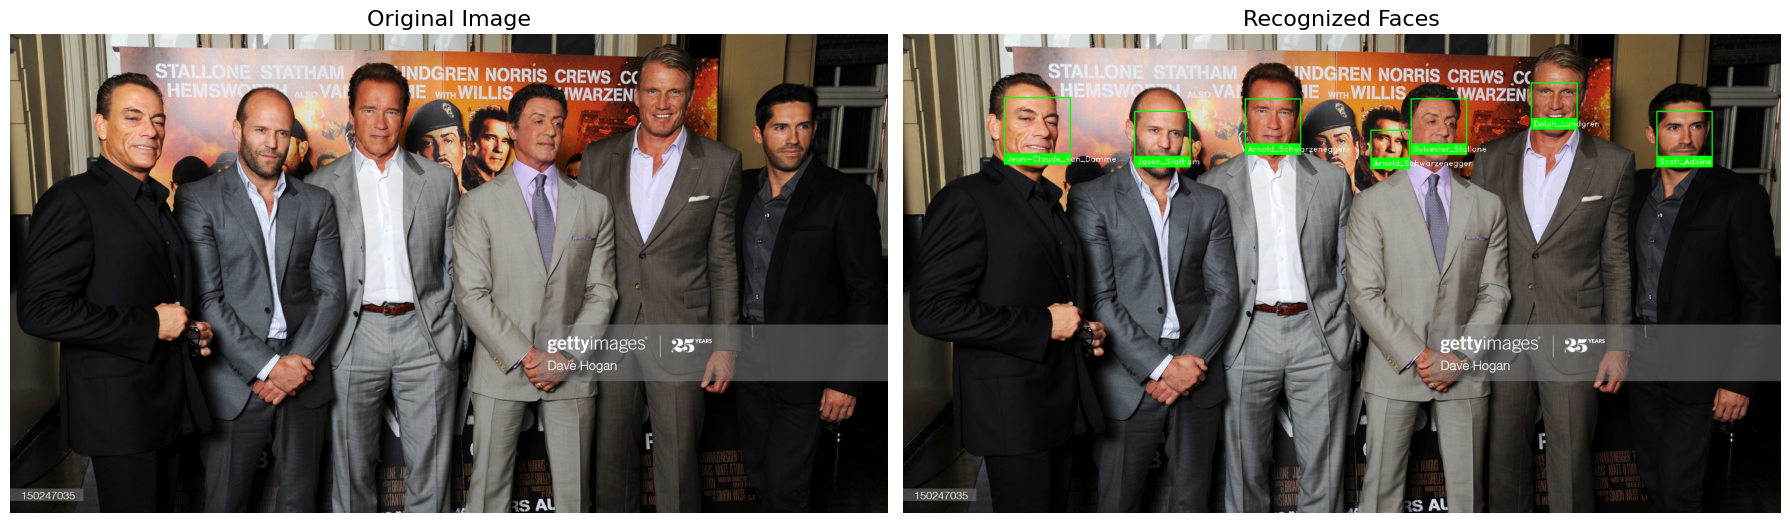


--- Відображення кожного зображення окремо ---



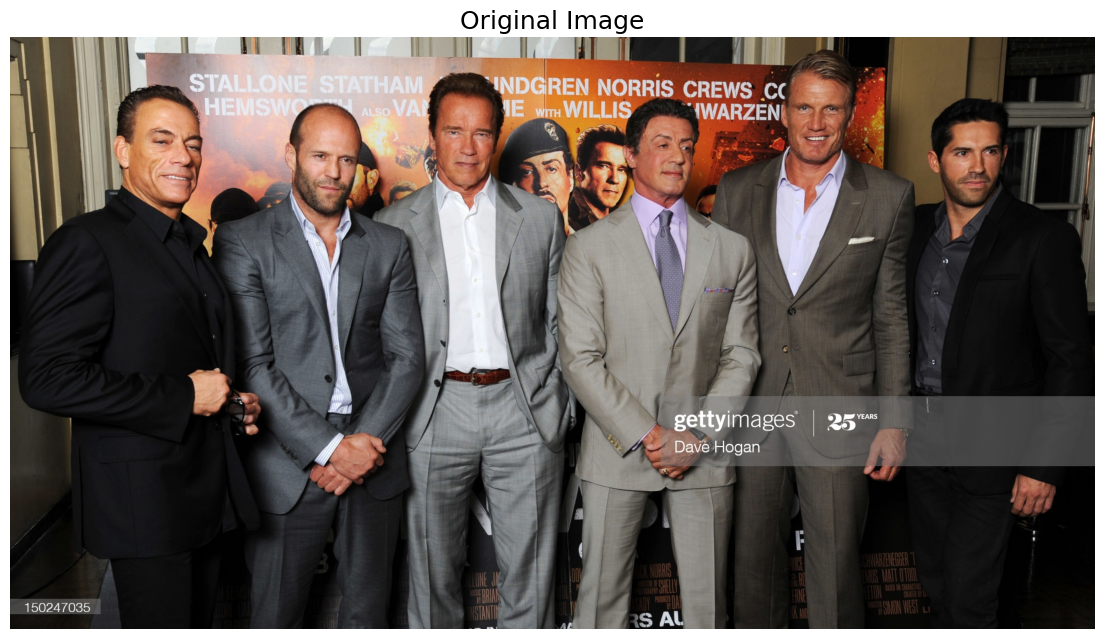

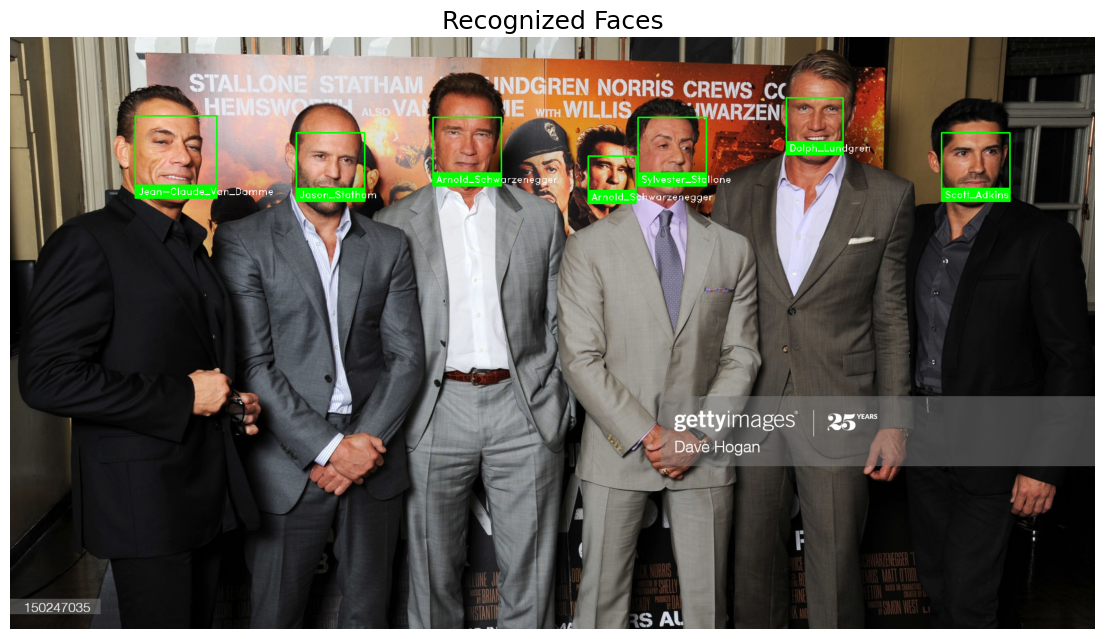

In [1]:
import os
import sys
import cv2
import dlib
import pickle
import numpy as np
import urllib.request
import zipfile
import bz2
import matplotlib.pyplot as plt

# ==============================================================================
# ЕТАП 0: НАЛАШТУВАННЯ СЕРЕДОВИЩА ТА ЗАВАНТАЖЕННЯ ФАЙЛІВ ДЛЯ KAGGLE
# ==============================================================================
print("=" * 70)
print("  Підготовка середовища Kaggle: Завантаження медіа та моделей...")
print("=" * 70)

ABSOLUTE_PATH = os.getcwd()
LAB_PATH = os.path.join(ABSOLUTE_PATH, "lab04")
DATASET_DIR = os.path.join(LAB_PATH, "dataset")
DLIB_DATA_PATH = os.path.join(LAB_PATH, "dlib_data")
PICKLE_FILE = os.path.join(LAB_PATH, "encodings.pickle")
TEST_IMAGE = os.path.join(LAB_PATH, "the_expendables_2.jpg")

# Створення необхідних директорій
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(DLIB_DATA_PATH, exist_ok=True)

# --- 1. Завантаження та розпакування датасету акторів ---
dataset_zip = os.path.join(LAB_PATH, "actors_dataset.zip")
if not os.path.exists(dataset_zip):
    print("[ІНФО] Завантаження actors_dataset.zip з GitHub...")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/refs/heads/main/lab04/actors_dataset.zip", dataset_zip)

print("[ІНФО] Розпакування датасету...")
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(DATASET_DIR)

# Якщо архів створив вкладену папку (наприклад, 'dataset/dataset/' або 'dataset/actors_dataset/'), витягуємо дані нагору
for folder_name in ["dataset", "actors_dataset"]:
    nested_path = os.path.join(DATASET_DIR, folder_name)
    if os.path.exists(nested_path) and os.path.isdir(nested_path):
        for item in os.listdir(nested_path):
            os.rename(os.path.join(nested_path, item), os.path.join(DATASET_DIR, item))
        os.rmdir(nested_path)

# --- 2. Завантаження тестового зображення ---
if not os.path.exists(TEST_IMAGE):
    print("[ІНФО] Завантаження тестового зображення...")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/refs/heads/main/lab04/the_expendables_2.jpg", TEST_IMAGE)

# --- 3. Завантаження масивних .dat моделей Dlib з офіційного джерела ---
def download_and_extract_bz2(url, output_path):
    if not os.path.exists(output_path):
        print(f"[ІНФО] Завантаження моделі Dlib (це може зайняти кілька хвилин): {url.split('/')[-1]} ...")
        bz2_path = output_path + ".bz2"
        urllib.request.urlretrieve(url, bz2_path)
        print(f"[ІНФО] Розпакування {output_path.split('/')[-1]} ...")
        with bz2.BZ2File(bz2_path, 'rb') as f_in, open(output_path, 'wb') as f_out:
            f_out.write(f_in.read())
        os.remove(bz2_path)

download_and_extract_bz2("http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2", 
                         os.path.join(DLIB_DATA_PATH, "shape_predictor_68_face_landmarks.dat"))
download_and_extract_bz2("http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2", 
                         os.path.join(DLIB_DATA_PATH, "dlib_face_recognition_resnet_model_v1.dat"))

print("[УСПІХ] Усі файли успішно підготовлені для роботи!\n")


# ==============================================================================
# МОДУЛЬ 1: utils.py (Інкапсульовано)
# ==============================================================================
USE_DLIB_DIRECT = True

if USE_DLIB_DIRECT:
    print("[UTILS] Налаштовано режим: Прямий конвеєр Dlib (Низький рівень)")
    dlib_detector = dlib.get_frontal_face_detector()
    try:
        dlib_predictor = dlib.shape_predictor(os.path.join(DLIB_DATA_PATH, "shape_predictor_68_face_landmarks.dat"))
        dlib_facerec = dlib.face_recognition_model_v1(os.path.join(DLIB_DATA_PATH, "dlib_face_recognition_resnet_model_v1.dat"))
    except RuntimeError:
        print("[ПОПЕРЕДЖЕННЯ] Не знайдено файли моделей '.dat' у папці проекту!")
else:
    print("[UTILS] Налаштовано режим: Високорівнева обгортка face_recognition")

def get_face_locations(image_path, model="hog"):
    if USE_DLIB_DIRECT:
        bgr_img = cv2.imread(image_path)
        if bgr_img is None:
            raise FileNotFoundError(f"Не вдалося завантажити зображення: {image_path}")
        rgb_image = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
        dets = dlib_detector(rgb_image, 1)
        locations = []
        for det in dets:
            locations.append((det.top(), det.right(), det.bottom(), det.left()))
        return locations, rgb_image

def get_face_encodings(image, face_locations):
    if USE_DLIB_DIRECT:
        encodings = []
        for (top, right, bottom, left) in face_locations:
            rect = dlib.rectangle(left, top, right, bottom)
            shape = dlib_predictor(image, rect)
            face_descriptor = dlib_facerec.compute_face_descriptor(image, shape)
            encoding_np = np.array(face_descriptor)
            encodings.append(encoding_np)
        return encodings

def nb_of_matches(known_person_encodings, test_encoding, tolerance=0.6):
    if USE_DLIB_DIRECT:
        match_count = 0
        for known_encoding in known_person_encodings:
            distance = np.linalg.norm(np.array(known_encoding) - np.array(test_encoding))
            if distance <= tolerance:
                match_count += 1
        return match_count


# ==============================================================================
# МОДУЛЬ 2: face_encoding.py (Інкапсульовано)
# ==============================================================================
def encode_dataset(dataset_path, output_pickle):
    print("[ІНФО] Початок генерації вкладень облич із набору даних...")
    known_encodings = {}

    if not os.path.exists(dataset_path):
        print(f"[ПОМИЛКА] Директорію '{dataset_path}' не знайдено! Створіть її.")
        return

    for person_name in os.listdir(dataset_path):
        person_dir = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_dir):
            continue
            
        print(f"[ІНФО] Обробка фотографій для: {person_name}")
        if person_name not in known_encodings:
            known_encodings[person_name] = []

        for image_name in os.listdir(person_dir):
            if not image_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            image_path = os.path.join(person_dir, image_name)
            try:
                locations, image = get_face_locations(image_path)
                encodings = get_face_encodings(image, locations)
                for encoding in encodings:
                    known_encodings[person_name].append(encoding)
            except Exception as e:
                print(f"[ПОМИЛКА] Не вдалося обробити файл {image_path}: {e}")

    print(f"[ІНФО] Збереження згенерованих вкладень у файл '{output_pickle}'...")
    with open(output_pickle, "wb") as f:
        pickle.dump(known_encodings, f)
    print("[УСПІХ] Процес завершено. Файл 'encodings.pickle' успішно створено!")


# ==============================================================================
# МОДУЛЬ 3: face_recognition_images.py (Інкапсульовано)
# ==============================================================================
def recognize_faces(test_image_path, pickle_path):
    print("[Інфо] Завантаження збереженої бази кодувань облич...")
    if not os.path.exists(pickle_path):
        print(f"[Помилка] Файл '{pickle_path}' не знайдено!")
        return None

    with open(pickle_path, "rb") as f:
        known_encodings = pickle.load(f)

    print(f"[ІНФО] Аналіз тестового зображення '{test_image_path}'...")
    if not os.path.exists(test_image_path):
        print(f"[Помилка] Тестове фото '{test_image_path}' не знайдено.")
        return None

    locations, rgb_image = get_face_locations(test_image_path)
    encodings = get_face_encodings(rgb_image, locations)

    bgr_output_image = cv2.imread(test_image_path)

    for (top, right, bottom, left), test_encoding in zip(locations, encodings):
        counts = {}
        for person_name, person_encodings in known_encodings.items():
            matches_count = nb_of_matches(person_encodings, test_encoding)
            counts[person_name] = matches_count

        name = "Unknown"
        if counts and max(counts.values()) > 0:
            name = max(counts, key=counts.get)

        cv2.rectangle(bgr_output_image, (left, top), (right, bottom), (0, 255, 0), 2)
        cv2.rectangle(bgr_output_image, (left, bottom - 25), (right, bottom), (0, 255, 0), cv2.FILLED)
        cv2.putText(bgr_output_image, name, (left + 6, bottom - 6), cv2.FONT_HERSHEY_DUPLEX, 0.6, (255, 255, 255), 1)

    # Замість cv2.imshow() ми повертаємо конвертоване RGB зображення для Matplotlib
    return cv2.cvtColor(bgr_output_image, cv2.COLOR_BGR2RGB)


# ==============================================================================
# МОДУЛЬ 4: lab04.py (Головний Керуючий Сценарій)
# ==============================================================================
def main():
    print("=" * 70)
    print("  Головний керуючий сценарій для лабораторної роботи №4")
    print("  Тема: Розпізнавання людини на фото з використанням бібліотеки Dlib")
    print("=" * 70)

    print("\n[КРОК 1/3] Перевірка наявності вхідних даних...")
    subdirs = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    print(f"[Успіх] Знайдено осіб для кодування: {len(subdirs)} ({', '.join(subdirs)})")

    print("\n[КРОК 2/3] Запуск процесу сканування та генерації цифрових відбитків облич...")
    print("-" * 70)
    encode_dataset(dataset_path=DATASET_DIR, output_pickle=PICKLE_FILE)
    print("-" * 70)

    print("\n[КРОК 3/3] Налаштування тестового зображення для ідентифікації...")
    print(f"[ІНФО] Запуск розпізнавання для файлу: '{TEST_IMAGE}'")
    print("-" * 70)
    
    result_image = recognize_faces(test_image_path=TEST_IMAGE, pickle_path=PICKLE_FILE)
    
    print("-" * 70)
    print("[ІНФО] Роботу головного оркестраційного скрипта лабораторної роботи №4' успішно завершено!")
    print("=" * 70)
    
    return result_image

# --- ВИКОНАННЯ ТА ВІЗУАЛІЗАЦІЯ ---
if __name__ == "__main__":
    final_result_img = main()

    # Відображення результатів (Grid та Separate)
    if final_result_img is not None:
        original_img_bgr = cv2.imread(TEST_IMAGE)
        original_img_rgb = cv2.cvtColor(original_img_bgr, cv2.COLOR_BGR2RGB)
        
        images_to_show = [
            ("Original Image", original_img_rgb),
            ("Recognized Faces", final_result_img)
        ]

        # --- GRID VIEW (СІТКА) ---
        print("\n--- Відображення загальної сітки зображень ---")
        fig, axes = plt.subplots(1, 2, figsize=(18, 9))
        for ax, (title, img) in zip(axes, images_to_show):
            ax.imshow(img)
            ax.set_title(title, fontsize=16)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

        # --- SEPARATE VIEW (ОКРЕМО) ---
        print("\n--- Відображення кожного зображення окремо ---\n")
        for title, img in images_to_show:
            plt.figure(figsize=(14, 14))
            plt.imshow(img)
            plt.title(title, fontsize=18)
            plt.axis('off')
            plt.show()